# Análise descritiva - Dados sobre casos de Dengue em Olímpia

## Imports e load dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
PATH = "../data/raw/dengue_1-53.csv"

In [3]:
df = pd.read_csv(PATH, sep=",")
df["data_iniSE"] = pd.to_datetime(df["data_iniSE"], format="%Y-%m-%d")
df = df.sort_values(by="data_iniSE").reset_index(drop=True)
df.head()

,data_iniSE,SE,casos_est,casos_est_min,casos_est_max,casos,p_rt1,p_inc100k,Localidade_id,nivel,...,umidmed,umidmin,tempmed,tempmax,casprov,casprov_est,casprov_est_min,casprov_est_max,casconf,notif_accum_year
0,2015-01-04,201501,1.0,1,1,1,0.322660,1.813894,0,2,...,62.775418,33.428571,26.106912,31.571429,1,NaN,NaN,NaN,NaN,27917
1,2015-01-11,201502,3.0,3,3,3,0.737415,5.441683,0,1,...,50.468360,29.571429,29.052166,34.571429,1,NaN,NaN,NaN,NaN,27917
2,2015-01-18,201503,4.0,4,4,4,0.821623,7.255578,0,1,...,52.418059,33.571429,28.135668,33.000000,2,NaN,NaN,NaN,NaN,27917
3,2015-01-25,201504,9.0,9,9,9,0.966992,16.325050,0,1,...,71.103953,46.571429,24.856409,30.000000,7,NaN,NaN,NaN,NaN,27917
4,2015-02-01,201505,15.0,15,15,15,0.986994,27.208416,0,1,...,70.510867,45.000000,24.649484,29.571429,7,NaN,NaN,NaN,NaN,27917


### Primeiras estatísticas

In [4]:
df["casos"].describe()

count    574.000000
mean      48.635889
std       92.129082
min        0.000000
25%        5.000000
50%       14.000000
75%       42.000000
max      528.000000
Name: casos, dtype: float64

In [5]:
iqr = df["casos"].quantile(0.75) - df["casos"].quantile(0.25)
print(f"Intervalo interquartil (IQR): {iqr}")

Intervalo interquartil (IQR): 37.0


Podemos ver aqui a média, mediana e os quartis dos casos semanais de dengue na cidade de Olímpia.
A média é muito superior à mediana (cerca de 3,5x maior), semanas com muitos casos notificados elevam a média, enquanto a mediana mostra uma semana típica.

Podemos ver também que metade das semanas ficam entre 5 e 42 casos IQR(37), mostrando que uma semana típica não possui muitas notificações de casos de dengue. 

Já o desvio padrão (std) é quase o dobro da média, uma vez que ele é sensivel a outliers.
Na nossa análise uma semana de surto não pode ser considerada um outlier, uma vez que o surto é objeto dessa análise, aquilo que queremos prever. 



In [7]:
media = df["casos"].mean()
desvio = df["casos"].std()
inferior = media - desvio
superior = media + desvio
proporcao_semanas = df["casos"].between(inferior, superior).mean()
print(f"A proporção de semanas dentro de 1 desvio padrão: {proporcao_semanas:.2%}")

A proporção de semanas dentro de 1 desvio padrão: 91.29%


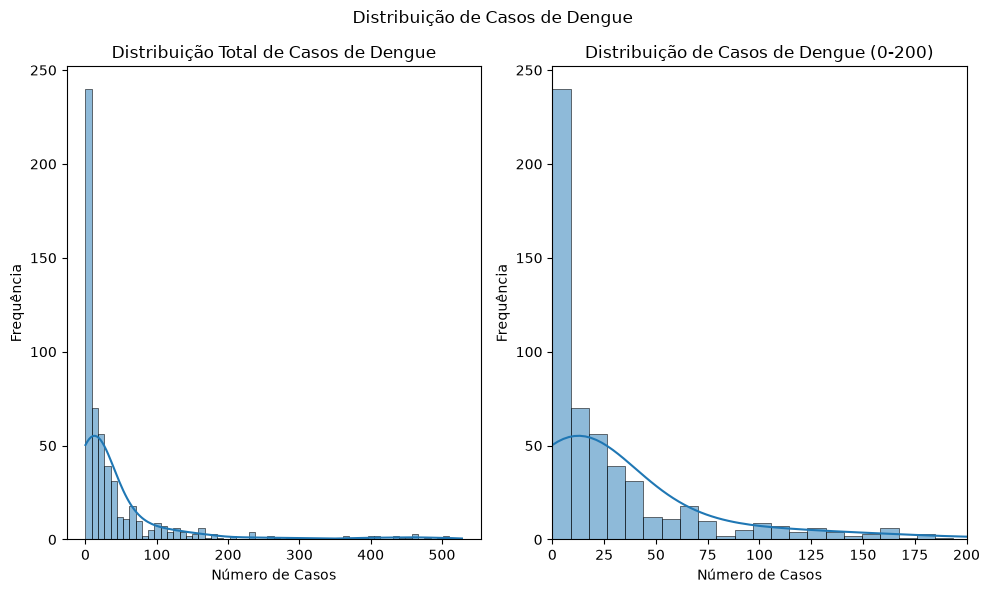

In [17]:
fig, axes = plt.subplots(1,2,figsize=(10, 6))
sns.histplot(df["casos"], bins="fd", kde=True, ax=axes[0])
axes[0].set_title("Distribuição Total de Casos de Dengue")
axes[0].set_xlabel("Número de Casos")
axes[0].set_ylabel("Frequência")
sns.histplot(df["casos"], bins="fd", kde=True, ax=axes[1])
plt.xlim(0,200)
axes[1].set_title("Distribuição de Casos de Dengue (0-200)")
axes[1].set_xlabel("Número de Casos")
axes[1].set_ylabel("Frequência")
plt.suptitle("Distribuição de Casos de Dengue ")
plt.tight_layout()  
plt.show()

Dessa proporção, junto com o histograma completo, podemos ver que ~91% das semanas caem dentro de um desvio padrão da média, contra 68% que seriam esperados numa distribuição normal. Isso se deve ao fato dos surtos inflarem o desvio padrão. Além disso, por se tratar de casos de uma doença, não faz sentido aceitar números negativos, logo os 9% restantes das semanas caem a direita (sentido positivo). Sendo assim, usar o par média ± desvio não cabe na nossa análise, sendo melhor trabalhar com a mediana e IQR